## Installation (GPU only)

pip install blue_sampler[gpu13] \
pip install blue_sampler[keops]

In [ ]:
!pip install --upgrade blue_sampler[gpu13]
!pip install --upgrade blue_sampler[keops]

In [2]:
import blue_sampler as blue
from blue_sampler.run.run_nufft_keops import _nufft_pipeline_keops as sample

from pathlib import Path
import zipfile

import h5py
import numpy as np

import time

#Fancy plots
import matplotlib.pyplot as plt
colrs = [c["color"] for c in plt.rcParams["axes.prop_cycle"]]
color = lambda i: colrs[i % len(colrs)]

#output path for the files
ROOT = Path(".")

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


## Sampling Configuration

### Mini experiment

The **mini** configuration is intended for quick experiments.

* **Dimension:** 2 to 8
* **Number of points:** \(N = 1,024\) to \(16,384\) (powers of two)
* **runtime:** approximately 2 minutes on a GPU
* **Reference hardware:** Google Colab T4

### Full experiment

Use the **full** configuration to reproduce the full sampling domain used in the paper.

* **Dimension:** 2 to 16
* **Number of points:** \(N = 1,024\) to \(131,072\)
* **runtime:** approximately 2 hour on a GPU

To run the mini resp full experiment, use:

```text
sampling = "mini" resp "all"
```

---

## NUFFT vs. NUFFT+

The **Chi** parameter of the gradient descent plays a crucial role in the optimization.

Chi controls the maximum wave vector included in the cost function. It affects both:

1. **Runtime:** larger values of Chi generally make the optimization slower to converge, requiring more iterations.
2. **Final sample quality:** larger Chi values improve the quality of the resulting point distribution in the high-frequency domain.

In practice:

* **Chi ≤ 0.35:** the optimization is relatively easy and fast.
* **Chi ≥ 0.43:** the optimization becomes significantly more difficult and require substantially more iterations.
* However, larger Chi values produce samples that are closer to the theoretical optimum, approaching the theoretical upper bound of **Chi = 0.5**.

See **Torcato et al.** for further details.


In [21]:
sampling = "mini" #or sampling = "all"
quality = "nufft+" #or quality = "nufft"

# "nufft" is 4 time faster than "nufft+" but not so good on high frequencys

assert sampling in ("mini", "all")
assert quality in ("nufft", "nufft+")

D_MIN = 2 # dimension D
POW_MIN = 10 # number of points N = 2**pow

D_MAX = 8 if sampling == "mini" else 16
POW_MAX = 14 if sampling == "mini" else 17

print(D_MAX, POW_MAX)

#see Torcato et. al for Chi parameter, NITER is the number of gradient steps
CHI, NITER = (0.43, 150) if quality == "nufft+" else (0.3, 150)

16 17


# Crash test

==== Test: nufft sampler (N = 1024) ====
D=2


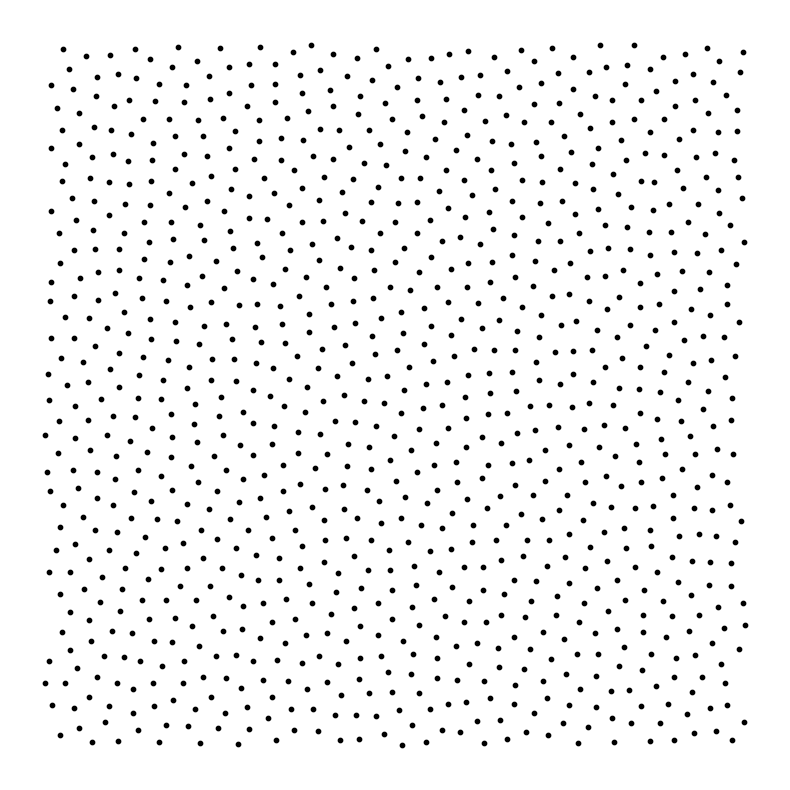

D=3
D=4
D=5
D=6
D=7
D=8
D=9
D=10
D=11
D=12
D=13
D=14
D=15
D=16
{'D2': {'N1024': {'0.07s'}}, 'D3': {'N1024': {'0.07s'}}, 'D4': {'N1024': {'0.08s'}}, 'D5': {'N1024': {'0.09s'}}, 'D6': {'N1024': {'0.09s'}}, 'D7': {'N1024': {'0.10s'}}, 'D8': {'N1024': {'0.11s'}}, 'D9': {'N1024': {'0.12s'}}, 'D10': {'N1024': {'0.12s'}}, 'D11': {'N1024': {'0.15s'}}, 'D12': {'N1024': {'0.14s'}}, 'D13': {'N1024': {'0.17s'}}, 'D14': {'N1024': {'0.17s'}}, 'D15': {'N1024': {'0.20s'}}, 'D16': {'N1024': {'0.20s'}}}


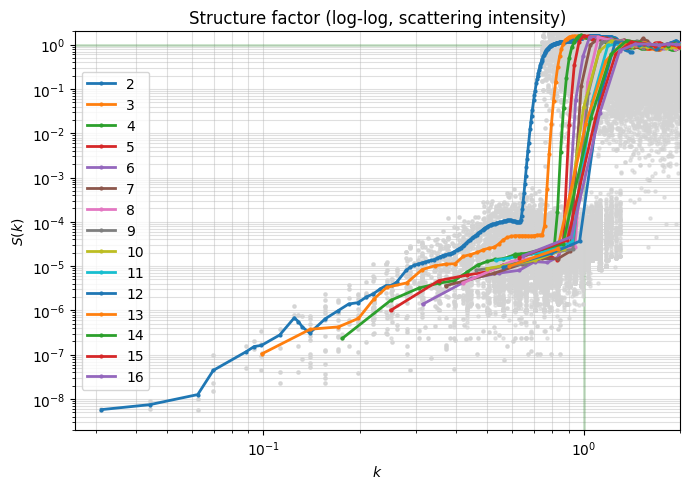

In [22]:
runtimes = {}
pow = 10
N = 2**pow
print(f"==== Test: nufft sampler (N = {N}) ====")
for D in range(D_MIN, D_MAX + 1):
    runtimes[f"D{D}"] = {}

    print(f"D={D}")

    start = time.time()

    x = sample(
        N,
        D,
        n_iter=NITER,
        verbose=0,
        Chi=CHI,
    )

    runtimes[f"D{D}"][f"N{N}"] = {f"{(time.time() - start):.2f}s"}

    if D == D_MIN:
        ax = None
    if D == 2:
        blue.plot(x)

    fig, ax = blue.plot_structure_factor(
                x, return_fig = True, label = D,
                color = color(D-D_MIN), ax = ax
              )

print(runtimes)
plt.show()

# Lets go

full pipeline


In [ ]:
runtimes = {}
for D in range(D_MIN, D_MAX + 1):
    runtimes[f"D{D}"] = {}
    print(f"\n=== Processing D={D} ===")

    npy_files = []

    # 1. Generate NPY files
    for pow in range(POW_MIN, POW_MAX + 1):
        N = 2**pow
        npy_path = ROOT / f"N{pow}_D{D}.npy"

        print(f"  Generating N={N} -> {npy_path.name}")

        start = time.time()

        x = sample(
            N,
            D,
            n_iter=NITER,
            verbose=0,
            Chi=CHI,
        )

        runtimes[f"D{D}"][f"N{N}"] = {f"{(time.time() - start):.2f}s"}

        np.save(npy_path, x)
        npy_files.append(npy_path)

    # 2. Convert NPY -> HDF5
    h5_files = []

    for npy_path in npy_files:
        h5_path = npy_path.with_suffix(".h5")

        points = np.load(npy_path)

        with h5py.File(h5_path, "w") as f:
            f.create_dataset(
                "points",
                data=points,
                dtype="float32",
            )

        h5_files.append(h5_path)

    # 3. Create D{D}.zip
    zip_path = ROOT / f"D{D}.zip"

    print(f"  Creating {zip_path.name}...")

    with zipfile.ZipFile(
        zip_path,
        mode="w",
        compression=zipfile.ZIP_DEFLATED,
    ) as z:
        for h5_path in h5_files:
            z.write(h5_path, arcname=h5_path.name)

    print(f"  Archive created: {zip_path.name}")

    # 4. Remove all intermediate NPY and HDF5 files
    for path in npy_files + h5_files:
        path.unlink()

    print("  Temporary NPY and HDF5 files removed.")
    print(f"=== D={D} completed ===")

print("\nAll dimensions completed.")

In [ ]:
print(runtimes)

{'D2': {'N1024': {'0.29s'}, 'N2048': {'0.37s'}, 'N4096': {'0.34s'}, 'N8192': {'0.46s'}, 'N16384': {'0.65s'}, 'N32768': {'1.48s'}, 'N65536': {'5.01s'}, 'N131072': {'19.31s'}}, 'D3': {'N1024': {'0.20s'}, 'N2048': {'0.23s'}, 'N4096': {'0.30s'}, 'N8192': {'0.46s'}, 'N16384': {'0.91s'}, 'N32768': {'2.83s'}, 'N65536': {'9.25s'}, 'N131072': {'36.95s'}}, 'D4': {'N1024': {'0.21s'}, 'N2048': {'0.26s'}, 'N4096': {'0.32s'}, 'N8192': {'0.53s'}, 'N16384': {'1.34s'}, 'N32768': {'4.33s'}, 'N65536': {'15.47s'}, 'N131072': {'58.27s'}}, 'D5': {'N1024': {'0.24s'}, 'N2048': {'0.30s'}, 'N4096': {'0.43s'}, 'N8192': {'0.86s'}, 'N16384': {'2.00s'}, 'N32768': {'6.09s'}, 'N65536': {'22.80s'}, 'N131072': {'86.99s'}}, 'D6': {'N1024': {'0.25s'}, 'N2048': {'0.33s'}, 'N4096': {'0.48s'}, 'N8192': {'0.89s'}, 'N16384': {'2.48s'}, 'N32768': {'8.38s'}, 'N65536': {'30.63s'}, 'N131072': {'118.72s'}}, 'D7': {'N1024': {'0.26s'}, 'N2048': {'0.33s'}, 'N4096': {'0.51s'}, 'N8192': {'1.14s'}, 'N16384': {'3.17s'}, 'N32768': {'10.97